---
title : "Dam Live"
---

In [1]:
# initialiseer de (toolbox continu inzicht) modules
from pathlib import Path

from toolbox_continu_inzicht.base.config import Config
from toolbox_continu_inzicht.base.data_adapter import DataAdapter

## Inladen van belastingen FEWS HHNK

<details>
<summary>Configuratie</summary>

```yaml
GlobalVariables:
    rootdir: "data_sets/run_damlive"
    moments: [ 0, 24 ]
    calc_time: "2024-11-06 08:00:00"
    aquo_alias:
        H.meting: "WATHTE"
        WATHTE [m][NAP][OW]: "WATHTE"

    LoadsFews:
        host: "https://fews.hhnk.nl"
        port: 443
        region: "fewspiservice"
        version: "1.25"
        parameters: [ "H.meting", "WATHTE [m][NAP][OW]" ]

DataAdapter:
    default_options:
        csv:
            sep: ","
    locaties:
        type: csv
        path: "locations_fews.csv"
    waterstanden:
        type: csv
        path: "hidden_waterstanden_fews.csv"
    waterstanden_xml:
        type: xml_timeseries
        path: "waterstanden_fews.xml"
        parameter_mapping:
            WATHTE: H.meting
        location_mapping:
            MPN-N-24: BP

```

</details>

In [2]:
config = Config(
    config_path=Path().cwd()
    / "data_sets"
    / "run_damlive"
    / "test_loads_fews_grondwater.yaml"
)
config.lees_config()

data_adapter = DataAdapter(config)

In [3]:
from toolbox_continu_inzicht.loads.loads_fews.loads_fews import LoadsFews


loads_fews = LoadsFews(data_adapter=data_adapter)

In [ ]:
df_out = loads_fews.run(input="locaties", output="waterstanden_xml")

: 

: 

In [4]:
data_adapter.input("waterstanden_xml")
file = data_adapter.config.data_adapters["waterstanden_xml"]["abs_path"]
with open(file) as f:
    xml_content = f.read()
# laast bovenste stukje van de xml zien
print(xml_content[:1300])

<?xml version="1.0" encoding="UTF-8"?>
<TimeSeries xmlns="http://www.wldelft.nl/fews/PI" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xsi:schemaLocation="http://www.wldelft.nl/fews/PI https://fewsdocs.deltares.nl/schemas/version1.0/pi-schemas/pi_timeseries.xsd" version="1.2">
	<timeZone>1.0</timeZone>
    <series>
        <header>
            <type>instantaneous</type>
            <locationId>PB-288</locationId>
            <parameterId>H.meting</parameterId>
            <timeStep unit="second" multiplier="3600"/>
            <startDate date="2024-11-06" time="08:00:00"/>
            <endDate date="2024-11-07" time="08:00:00"/>
            <missVal>-999.0</missVal>
            <stationName>PB-288</stationName>
            <units>m</units>
        </header>
        <event date="2024-11-06" time="08:00:00" value="-2.145" flag="0"/>
        <event date="2024-11-06" time="09:00:00" value="-2.148" flag="0"/>
        <event date="2024-11-06" time="10:00:00" value="-2.145" flag="0"/>

Voor het geval dat FEWS HHNK niet beschikbaar is, kan met het volgende bestand wel gerekend worden.
In het voorbeeld van FEWS hierboven is het een xml bestand maar elke tabel met meetreeks data kan gebruikt worden.

Bijvoorbeeld de csv:

```yaml
...
waterstanden:
    type: csv
    path: "waterstanden_fews.csv"
...
```

In [5]:
data_adapter.input("waterstanden_xml")

,date_time,measurement_location_code,parameter_code,parameter_id,unit,value,measurement_location_id
0,2024-11-06 07:00:00+00:00,PB-288,H.meting,5663076,m,-2.145,6401110
1,2024-11-06 08:00:00+00:00,PB-288,H.meting,5663076,m,-2.148,6401110
2,2024-11-06 09:00:00+00:00,PB-288,H.meting,5663076,m,-2.145,6401110
3,2024-11-06 10:00:00+00:00,PB-288,H.meting,5663076,m,-2.152,6401110
4,2024-11-06 11:00:00+00:00,PB-288,H.meting,5663076,m,-2.149,6401110
...,...,...,...,...,...,...,...
192,2024-11-07 06:00:00+00:00,BP,H.meting,5663076,m,-0.466,5605741
193,2024-11-07 06:15:00+00:00,BP,H.meting,5663076,m,-0.475,5605741
194,2024-11-07 06:30:00+00:00,BP,H.meting,5663076,m,-0.464,5605741
195,2024-11-07 06:45:00+00:00,BP,H.meting,5663076,m,-0.485,5605741


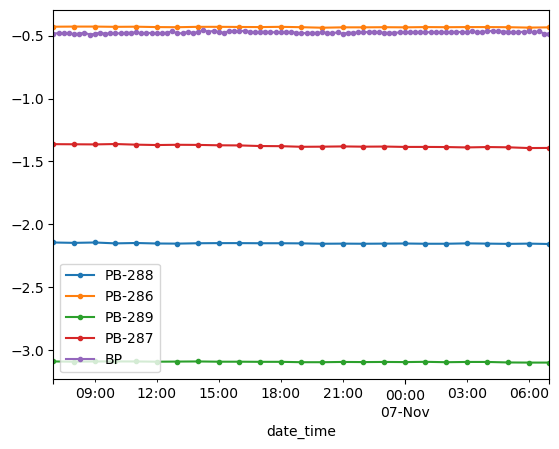

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
df_waterstanden = data_adapter.input("waterstanden_xml")
for station in df_waterstanden["measurement_location_code"].unique():
    df_station = df_waterstanden[
        df_waterstanden["measurement_location_code"] == station
    ].copy()
    df_station.rename(columns={"value": station}, inplace=True)
    df_station.plot(x="date_time", y=station, ax=ax, legend=station, marker=".")

# loads to moments

Een deel van de data vanuit fews komt als kwartier data binnen, om dit naar uren te zetten wordt loads to moments gebruikt

In [8]:
from toolbox_continu_inzicht.loads import LoadsToMoments

Voor dit voorbeeld doen we nu even 2 tijdstappen

In [9]:
data_adapter.set_global_variable("moments", [i for i in range(0, 2, 1)])

In [10]:
loads_to_moments = LoadsToMoments(data_adapter=data_adapter)
loads_to_moments.run(input="waterstanden_xml", output="waterstanden_xml_hourly")

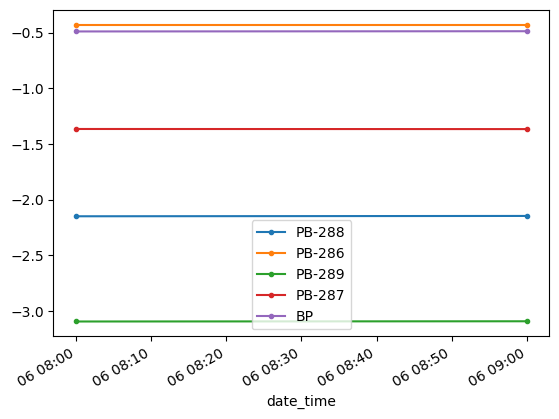

In [11]:
fig, ax = plt.subplots()
df_waterstanden = loads_to_moments.df_out
for station in df_waterstanden["measurement_location_code"].unique():
    df_station = df_waterstanden[
        df_waterstanden["measurement_location_code"] == station
    ].copy()
    df_station.rename(columns={"value": station}, inplace=True)
    df_station.plot(x="date_time", y=station, ax=ax, legend=station, marker=".")

## Runnen van dam_live

Voor [DamLive](https://publicwiki.deltares.nl/spaces/DAM/pages/160236931/Gebruikershandleiding+DAM-Live) is een licentie van Deltares nodig.

Dit voorbeeld is gemaakt met een versie van damlive versie 26.1.0.7015.


In [12]:
# initialiseer de (toolbox continu inzicht) modules
from pathlib import Path

from toolbox_continu_inzicht.base.config import Config
from toolbox_continu_inzicht.base.data_adapter import DataAdapter


<details>
<summary> Configuratie</summary>

```yaml
GlobalVariables:
    rootdir: "data_sets/run_damlive"
    moments: [ 0, 24 ]
    calc_time: "2024-11-06 08:00:00"
    UpdateDamLive:
        DAMLIVE_FILE: 'WV2030_Purmer.damx'
        delete_output_folder: False

DataAdapter:
    default_options:
        csv:
            sep: ","
    waterstanden_xml_uur:
        type: xml_timeseries
        path: "waterstanden_fews_hourly.xml"
    parameters_bishop_csv:
        type: csv
        index: True
        path: "parameters_bishop.csv"
    parameters_uplift_csv:
        type: csv
        index: True
        path: "parameters_uplift.csv"
    output_file:
        type: csv
        path: test.csv

``` 
</details>


In [13]:
config = Config(
    config_path=Path().cwd() / "data_sets" / "run_damlive" / "run_damlive.yaml"
)
config.lees_config()

data_adapter = DataAdapter(config)

De benoemde waterstand metingen tabel moet mee gegeven worden

In [14]:
data_adapter.input("waterstanden_xml_uur")

,date_time,measurement_location_code,parameter_code,parameter_id,unit,value,measurement_location_id
0,2024-11-06 07:00:00+00:00,PB-288,H.meting,5663076,m,-2.148,6401110
1,2024-11-06 08:00:00+00:00,PB-288,H.meting,5663076,m,-2.145,6401110
2,2024-11-06 07:00:00+00:00,PB-286,H.meting,5663076,m,-0.428,3365141
3,2024-11-06 08:00:00+00:00,PB-286,H.meting,5663076,m,-0.428,3365141
4,2024-11-06 07:00:00+00:00,PB-289,H.meting,5663076,m,-3.093,1421399
5,2024-11-06 08:00:00+00:00,PB-289,H.meting,5663076,m,-3.091,1421399
6,2024-11-06 07:00:00+00:00,PB-287,H.meting,5663076,m,-1.364,5779152
7,2024-11-06 08:00:00+00:00,PB-287,H.meting,5663076,m,-1.365,5779152
8,2024-11-06 07:00:00+00:00,BP,H.meting,5663076,m,-0.488,5605741
9,2024-11-06 08:00:00+00:00,BP,H.meting,5663076,m,-0.486,5605741


En de parameters moeten ook nog worden mee geven, in dit geval rekenen we met bishop

Daarnaast moet in de `root_dir` een `{project_naam}.damx` bestand staan wat uitvoer is van een [`Dam stabiliteit`](https://publicwiki.deltares.nl/spaces/DAM/pages/166462239/Aanmaken+DAM+Live+project) berekening, en een map met de stix bestanden: `{project_naam}.geometries2D` waar in het `.damx` bestand naar wordt verwezen. 

In dit voorbeeld is de `project_naam`:  `WV2030_Purmer`. 

Het projectnaam moet meegeven worden in de opties, 

In [15]:
from toolbox_continu_inzicht.dam_live import UpdateDamLive

update_dam_live = UpdateDamLive(data_adapter=data_adapter)

In [16]:
# om meer informatie terug te krijgen van DAMLIVE, kan de logging level op INFO worden gezet.
update_dam_live.data_adapter.set_global_variable("logging", {"level": "INFO"})
update_dam_live.data_adapter.init_logging(re_initialize=True)

Dit duurt ca 2 min voor 2 tijdstappen: 

In [17]:
update_dam_live.run(
    input=["waterstanden_xml_uur", "parameters_bishop_csv"], output="output_file"
)

2026-03-19 16:07:11 INFO - run: 2026-03-19 16:07:11,419 [1] INFO  DamLive DamLive 26.1.0.7015
2026-03-19 16:07:11 INFO - run: 2026-03-19 16:07:11,426 [1] INFO  DamLive Copyright ¸ Deltares 2026
2026-03-19 16:07:11 INFO - run: 2026-03-19 16:07:11,426 [1] INFO  DamLive Model runner started
2026-03-19 16:07:11 INFO - run: 
2026-03-19 16:09:58 INFO - run: 2026-03-19 16:09:58,507 [1] INFO  Deltares.DamLive.Application.DamEngineRunner There are 16 locations with sensor data
2026-03-19 16:09:58 INFO - run: 
2026-03-19 16:09:58 INFO - run: 2026-03-19 16:09:58,532 [1] INFO  DamLive Model runner ended


In [17]:
df_output_damlive = update_dam_live.data_adapter.input("output_file")
df_output_damlive.head(5)

,Unnamed: 0,date_time,measurement_location_code,parameter_code,parameter_id,unit,value,measurement_location_id
0,0,2024-11-06 06:00:00+00:00,PU0013_87074-1_DWP001,StabilityInsideFactor,7310765,m,1.047054,1063233
1,1,2024-11-06 07:00:00+00:00,PU0013_87074-1_DWP001,StabilityInsideFactor,7310765,m,1.047253,1063233
2,2,2024-11-06 06:00:00+00:00,PU0021_87074-1_DWP002,StabilityInsideFactor,7310765,m,0.846680,1976182
3,3,2024-11-06 07:00:00+00:00,PU0021_87074-1_DWP002,StabilityInsideFactor,7310765,m,0.846996,1976182
4,4,2024-11-06 06:00:00+00:00,PU0030_87074-1_DWP003,StabilityInsideFactor,7310765,m,0.817755,1923656


## Verwerken van figuur data

Nu de berekening klaar is kunnen we de bestanden uitpakken. 

Mocht je problemen hebben met het uitpakken van de bestanden, kan het door de maximale pad naam lengthe van windows komen. De namen van de DamLive bestanden zijn vrij lang. 
Zie deze [gist](https://gist.github.com/leodutra/a25bc1f51e8779943df0a95d5a4839d1#windows-11) voor een oplossing

In [18]:
update_dam_live.unzip_damlive_results()

In [19]:
from toolbox_continu_inzicht.dam_live import CombineDamLiveResults

In [20]:
config = Config(
    config_path=Path().cwd()
    / "data_sets"
    / "run_damlive"
    / "dam_live_parse_config.yaml"
)
config.lees_config()

data_adapter = DataAdapter(config)

In [21]:
# na het uitpakken slaan we de resulterende bestandsnamen op, deze kunnen we hier weer inlezen
# dit is een voorbeeld specifiek voor deze configuratie en je paden, daarom is het niet in de functie verwerkt.
unziped_dirs = [
    str(path).split("development_notebooks\\dam_live\\")[1]
    for path in update_dam_live.lst_unzipped_damlive_results
]
# uit de bestands namen halen we de locatie en tijdstap, hier koppelen we vervolgens weer met de output dataframe
loc_time = [
    (fname.split("\\")[-1].split(".")[0], fname.split("\\")[-1].split(".")[-1])
    for fname in unziped_dirs
]
print(f"unzipped {len(unziped_dirs)} dirs")
unziped_dirs[:5]

unzipped 65 dirs


['data_sets\\run_damlive\\WV2030_Purmer.Calc\\Stability\\Bishop\\PU0013_87074-1_DWP001.0.2024-11-06T07',
 'data_sets\\run_damlive\\WV2030_Purmer.Calc\\Stability\\Bishop\\PU0013_87074-1_DWP001.0.2024-11-06T07',
 'data_sets\\run_damlive\\WV2030_Purmer.Calc\\Stability\\Bishop\\PU0013_87074-1_DWP001.1.2024-11-06T08',
 'data_sets\\run_damlive\\WV2030_Purmer.Calc\\Stability\\Bishop\\PU0021_87074-1_DWP002.0.2024-11-06T07',
 'data_sets\\run_damlive\\WV2030_Purmer.Calc\\Stability\\Bishop\\PU0021_87074-1_DWP002.1.2024-11-06T08']

We kunnen nu een van de resultaten bekijken:

In [22]:
run_index = 1
config.global_variables["rootdir"] = unziped_dirs[run_index]

In [23]:
combine_damlive_results = CombineDamLiveResults(data_adapter)

In [24]:
combine_damlive_results.run(
    input=[
        "scenario",
        "geometries",
        "soils",
        "soillayers",
        "waternets",
        "calculationsettings",
        "colors",
    ],
    output=["merge_soil", "merge_waternet", "merge_calculations"],
)
stage_id = list(combine_damlive_results.df_merged_soils.stage_id.unique())

De DamLive .stix resultaten kunnen we koppelen and het timeseries output bestand met locatie en tijd

In [25]:
import datetime

# in dit geval is de tijdzone van de output +1 uur, dus die wordt hier nog goed gezet voor het filteren
tz = datetime.timezone(datetime.timedelta(hours=1))
loc, time = loc_time[run_index]
date_time = df_output_damlive["date_time"].apply(
    lambda x: datetime.datetime.fromisoformat(x).astimezone(tz).strftime("%Y-%m-%dT%H")
)
df_corresponding_output = df_output_damlive[
    (df_output_damlive["measurement_location_code"] == loc) & (date_time == time)
]
df_corresponding_output

,Unnamed: 0,date_time,measurement_location_code,parameter_code,parameter_id,unit,value,measurement_location_id
0,0,2024-11-06 06:00:00+00:00,PU0013_87074-1_DWP001,StabilityInsideFactor,7310765,m,1.047054,1063233
32,32,2024-11-06 06:00:00+00:00,PU0013_87074-1_DWP001,BishopCircleCentreX,3911198,m,39.660000,1063233
64,64,2024-11-06 06:00:00+00:00,PU0013_87074-1_DWP001,BishopCircleCentreZ,7971454,m,18.730000,1063233
96,96,2024-11-06 06:00:00+00:00,PU0013_87074-1_DWP001,BishopCircleRadius,9374308,m,24.680000,1063233


En vervolgens plotten

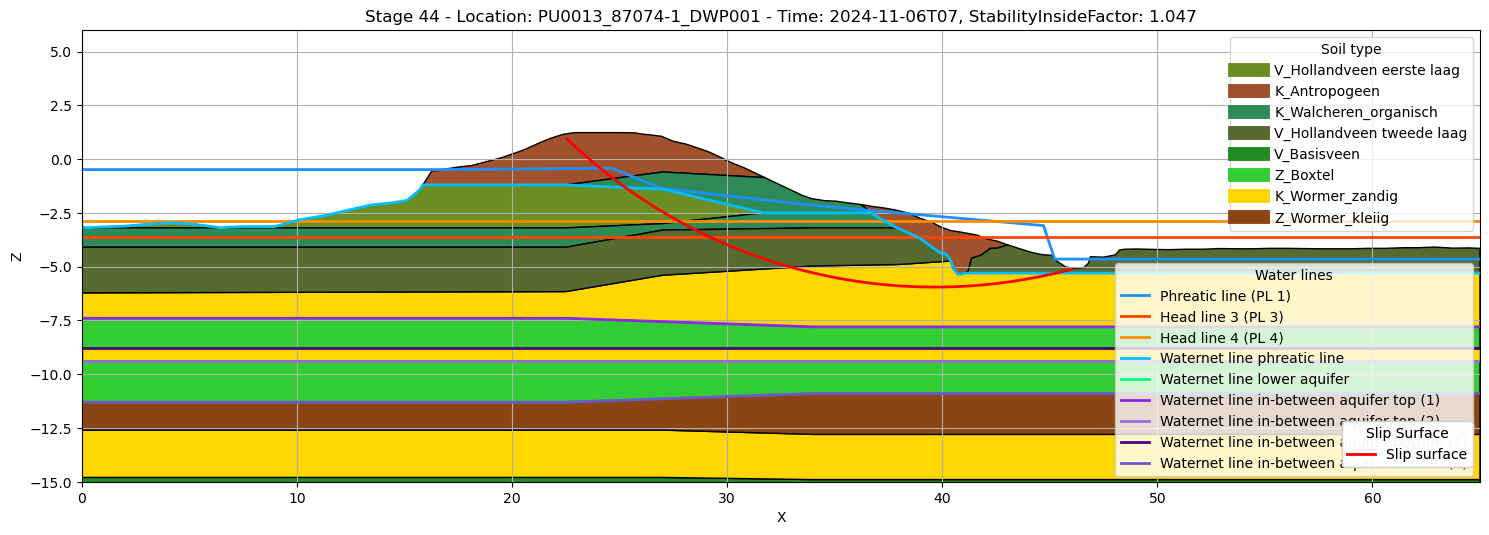

In [26]:
import matplotlib.pyplot as plt

fig, ax = combine_damlive_results.plot_stage(
    stage_id=int(stage_id[0]),
    xlim=(0, 65),
    ylim=(-15, 6),
)
sf = df_corresponding_output.set_index("parameter_code").loc[
    "StabilityInsideFactor", "value"
]
ax.set_title(
    f"Stage {stage_id[0]} - Location: {loc} - Time: {time}, StabilityInsideFactor: {sf:.3f}"
);

Als we alle bovenstaande stappen achter elkaar doen krijgen we een interactieve widget:

In [32]:
from ipywidgets import widgets


def make_widget(run_index):
    config.global_variables["rootdir"] = unziped_dirs[run_index]
    combine_damlive_results = CombineDamLiveResults(data_adapter)
    combine_damlive_results.run(
        input=[
            "scenario",
            "geometries",
            "soils",
            "soillayers",
            "waternets",
            "calculationsettings",
            "colors",
        ],
        output=["merge_soil", "merge_waternet", "merge_calculations"],
    )
    stage_id = list(combine_damlive_results.df_merged_soils.stage_id.unique())
    tz = datetime.timezone(datetime.timedelta(hours=1))
    loc, time = loc_time[run_index]
    date_time = df_output_damlive["date_time"].apply(
        lambda x: datetime.datetime.fromisoformat(x)
        .astimezone(tz)
        .strftime("%Y-%m-%dT%H")
    )
    df_corresponding_output = df_output_damlive[
        (df_output_damlive["measurement_location_code"] == loc) & (date_time == time)
    ]
    fig, ax = combine_damlive_results.plot_stage(
        stage_id=int(stage_id[0]),
        xlim=(0, 65),
        ylim=(-15, 6),
    )
    sf = df_corresponding_output.set_index("parameter_code").loc[
        "StabilityInsideFactor", "value"
    ]
    ax.set_title(
        f"Stage {stage_id[0]} - Location: {loc} - Time: {time}, StabilityInsideFactor: {sf:.3f}"
    )


widgets.interact(
    make_widget,
    run_index=widgets.IntSlider(
        value=2,
        min=0,
        max=33,
        step=1,
        description="run_index",
        continuous_update=False,
    ),
);

interactive(children=(IntSlider(value=2, continuous_update=False, description='run_index', max=33), Output()),…

## Herhaal met UpliftVan

Dit duurt ca 5min voor 2 tijdstappen: 

In [ ]:
update_dam_live.run(
    input=["waterstanden_xml_uur", "parameters_uplift_csv"], output="output_file"
)

In [28]:
update_dam_live.data_adapter.input("output_file").head(5)

,Unnamed: 0,date_time,measurement_location_code,parameter_code,parameter_id,unit,value,measurement_location_id
0,0,2024-11-06 06:00:00+00:00,PU0013_87074-1_DWP001,StabilityInsideFactor,7310765,m,1.047054,1063233
1,1,2024-11-06 07:00:00+00:00,PU0013_87074-1_DWP001,StabilityInsideFactor,7310765,m,1.047253,1063233
2,2,2024-11-06 06:00:00+00:00,PU0021_87074-1_DWP002,StabilityInsideFactor,7310765,m,0.846680,1976182
3,3,2024-11-06 07:00:00+00:00,PU0021_87074-1_DWP002,StabilityInsideFactor,7310765,m,0.846996,1976182
4,4,2024-11-06 06:00:00+00:00,PU0030_87074-1_DWP003,StabilityInsideFactor,7310765,m,0.817755,1923656


In [29]:
update_dam_live.unzip_damlive_results()
unziped_dirs = [
    str(path).split("development_notebooks\\dam_live\\")[1]
    for path in update_dam_live.lst_unzipped_damlive_results
]
loc_time = [
    (fname.split("\\")[-1].split(".")[0], fname.split("\\")[-1].split(".")[-1])
    for fname in unziped_dirs
]
print(f"unzipped {len(unziped_dirs)} dirs")
# dit is zowel bischop als uplift, voor nu alleen bischop gebruiken
unziped_dirs[33:38]

unzipped 65 dirs


['data_sets\\run_damlive\\WV2030_Purmer.Calc\\Stability\\UpliftVan\\PU0013_87074-1_DWP001.0.2024-11-06T07',
 'data_sets\\run_damlive\\WV2030_Purmer.Calc\\Stability\\UpliftVan\\PU0013_87074-1_DWP001.1.2024-11-06T08',
 'data_sets\\run_damlive\\WV2030_Purmer.Calc\\Stability\\UpliftVan\\PU0021_87074-1_DWP002.0.2024-11-06T07',
 'data_sets\\run_damlive\\WV2030_Purmer.Calc\\Stability\\UpliftVan\\PU0021_87074-1_DWP002.1.2024-11-06T08',
 'data_sets\\run_damlive\\WV2030_Purmer.Calc\\Stability\\UpliftVan\\PU0030_87074-1_DWP003.0.2024-11-06T07']

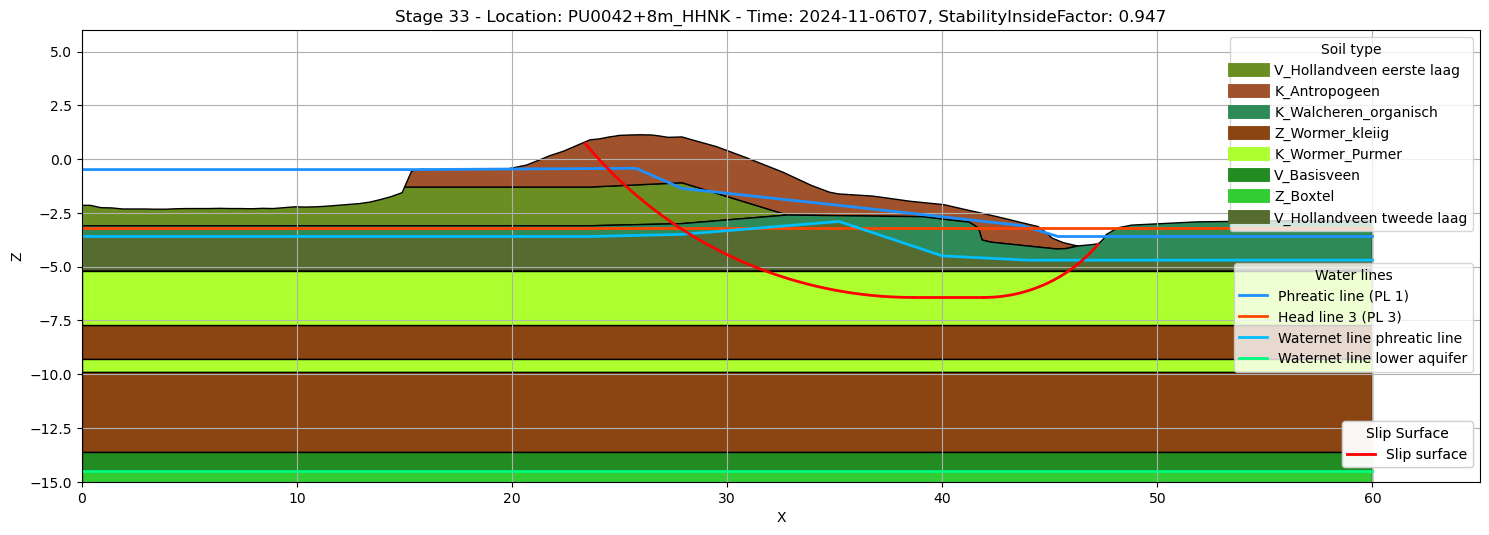

In [38]:
make_widget(39)

In [33]:
widgets.interact(
    make_widget,
    run_index=widgets.IntSlider(
        value=33,
        min=33,
        max=len(unziped_dirs) - 1,
        step=1,
        description="run_index",
        continuous_update=False,
    ),
);

interactive(children=(IntSlider(value=33, continuous_update=False, description='run_index', max=64, min=33), O…